# eps_rel damping at full polar — local-basin comparison (opc r=256 + r=64, OLMo + Llama)

**Stream A.** At full polar, does one fixed relative-damping value flatten the local lr basin (lr × {1/3,1,3} around each model's own full-polar optimum) on the weak model (OLMo) **without hurting** Llama? Scope: full-polar arms (ns≥8 / polar-express) + the ns=5 partial-polar reference + AdamW; SSC-clip variants excluded. Labels/colors come from the shared `canonical_label` / `canonical_colors` (AdamW black + first; every axis explicit, so no silent merge — the figure's `assert_label_discriminates` guard hard-errors otherwise). `allow_partial=True`. σ proxy 0.0017.

Same comparison run at **r=256** (top two cells) and **r=64** (bottom two). The r=64 eps_rel arms mirror the r=256 campaign (ns8), with lrs centered on r=64's own full-polar optimum (OLMo k1≈1e-2 / k2≈3e-2; Llama ≈3e-3).

NOTE: OLMo's full-abs reference is `polar-express` (no ns=8-abs run exists on OLMo); Llama's is `ns=8` — labeled honestly by `canonical_label`, not folded. polar-express is a full-polar reference exactly like ns≥8 — `damping_scope` folds both as full.

In [ ]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
import matplotlib.pyplot as plt
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from lora_playground.loader import load_runs
from lora_playground.plotting import compare_variants_figure, canonical_label
from IPython.display import display

OPT_ADAMW    = 'adamw'
OPT_CT       = 'adam-polar-product-lora-coupled-spectral-chord-tight'
OPT_CT_CLEAN = 'adam-polar-product-lora-coupled-spectral-chord-tight-clean'

def ns_of(cfg):
    oc = cfg.get('optimizer_config') or {}
    return cfg.get('muon_ns_steps', oc.get('ns_steps'))
def picard_of(cfg):
    return cfg.get('_derived', {}).get('effective_picard_iters', cfg.get('picard_iters_override')) or 1

def damping_scope(cfg):
    '''Restrict to the full-polar damping comparison, then label via the SHARED
    canonical_label (consistent names everywhere; no hand-rolled strings).'''
    opt = cfg.get('optimizer')
    if opt == OPT_ADAMW: return 'AdamW'
    if opt not in (OPT_CT, OPT_CT_CLEAN): return None
    if cfg.get('ssc_kappa') is not None or cfg.get('ssc_c') is not None: return None  # exclude clip
    ns = ns_of(cfg); pm = cfg.get('polar_method')
    full = (pm == 'polar_express') or (ns is not None and ns >= 8)
    rel = cfg.get('precond_delta_relative')
    if full:                                       # full-polar arms (ns>=8 / polar-express)
        return canonical_label(cfg)
    if opt == OPT_CT and ns == 5 and not rel:      # plain chord-tight ns=5 partial-polar reference only
        return canonical_label(cfg)
    return None

def render_damp(groups, suptitle):
    runs = load_runs(where={'log_group': groups}, logs_root='../logs',
                     warn_cross_commit=False, quiet=True)
    dedup = {}
    for cfg, hist in runs:
        key = (cfg['optimizer'], float(cfg['lr']), ns_of(cfg), cfg.get('polar_method'),
               cfg.get('precond_delta'), cfg.get('precond_delta_relative'), picard_of(cfg))
        if key not in dedup or len(hist) > len(dedup[key][1]):
            dedup[key] = (cfg, hist)
    labeled = [(c, h) for c, h in dedup.values() if damping_scope(c) is not None]
    labels = {damping_scope(c) for c, _ in labeled}
    print(f'{len(labeled)} labeled runs -> {sorted(labels)}')
    # variant_key=damping_scope (canonical labels); colors default -> AdamW black+first.
    # compare_variants_figure runs assert_label_discriminates internally.
    fig, tdf, sdf = compare_variants_figure(
        variants={l: {} for l in labels}, common_where={}, ref_label='AdamW',
        target_label='AdamW', sigma_ref=0.0017, suptitle=suptitle,
        max_steps=9000, allow_partial=True,
        prefetched_runs=labeled, variant_key=damping_scope)
    display(tdf.style.format('{:.4f}', na_rep='—'))
    display(sdf.style.format({'final': '{:.4f}', 'delta': '{:+.4f}',
                              'delta_sigma': '{:+.2f}σ', 'best_lr': '{:.0e}'}, na_rep='—'))
    plt.show()
    return tdf, sdf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## OLMo-2-1B × opc × r=256 — the weak/blowup model (full-polar optimum ≈ 1e-2)

28 labeled runs -> ['AdamW', 'chord-tight PE=10 k=1 (abs)', 'chord-tight ns=5 k=1 (abs)', 'chord-tight ns=8 k=1 (ε_rel=1e-1)', 'chord-tight ns=8 k=1 (ε_rel=1e-2)', 'chord-tight ns=8 k=1 (ε_rel=1e-3)', 'chord-tight-clean ns=8 k=2 (ε_rel=1e-2)']


,AdamW,chord-tight PE=10 k=1 (abs),chord-tight ns=5 k=1 (abs),chord-tight ns=8 k=1 (ε_rel=1e-1),chord-tight ns=8 k=1 (ε_rel=1e-2),chord-tight ns=8 k=1 (ε_rel=1e-3),chord-tight-clean ns=8 k=2 (ε_rel=1e-2)
lr,,,,,,,
0.000030,0.7760,—,—,—,—,—,—
0.000100,0.7524,—,—,—,—,—,—
0.000300,0.7952,—,—,—,—,—,—
0.001000,1.1470,—,—,—,—,—,—
0.003000,2.6515,0.7425,0.7670,0.7432,0.7457,0.7462,—
0.010000,—,0.7414,0.7453,0.7476,0.7399,0.7386,—
0.030000,—,0.7737,0.7388,—,0.7570,0.7491,—
0.100000,—,0.8763,0.7424,—,0.8087,—,—
0.300000,—,1.0078,0.7538,—,—,—,—


,variant,best_lr,final,delta,delta_sigma
0,AdamW,1e-04,0.7524,—,—
1,chord-tight PE=10 k=1 (abs),1e-02,0.7414,-0.0111,-6.52σ
2,chord-tight ns=5 k=1 (abs),3e-02,0.7388,-0.0136,-8.01σ
3,chord-tight ns=8 k=1 (ε_rel=1e-1),3e-03,0.7432,-0.0092,-5.44σ
4,chord-tight ns=8 k=1 (ε_rel=1e-2),1e-02,0.7399,-0.0125,-7.36σ
5,chord-tight ns=8 k=1 (ε_rel=1e-3),1e-02,0.7386,-0.0138,-8.12σ


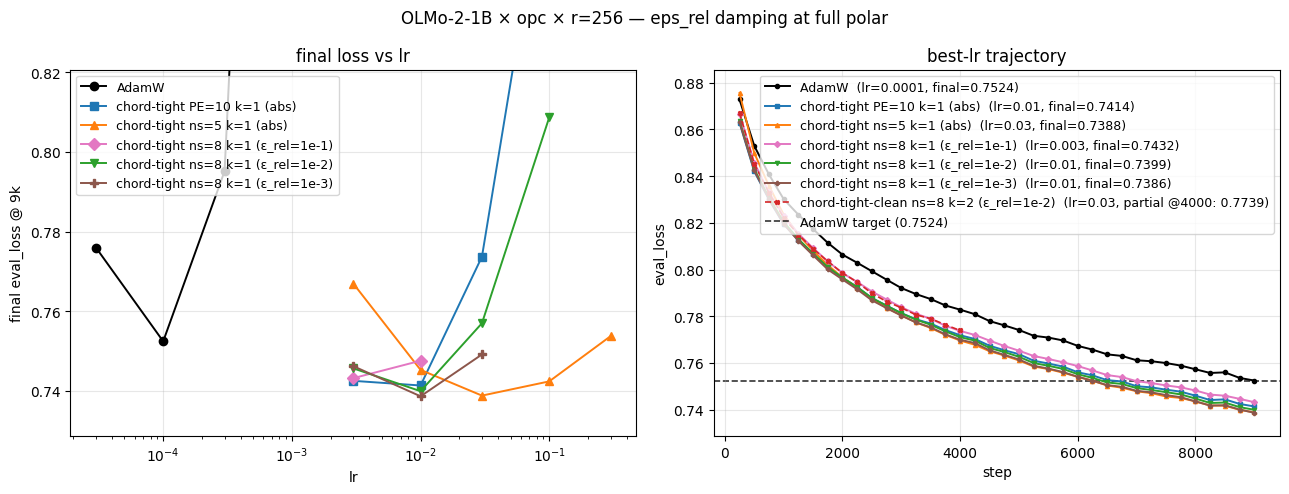

In [ ]:
OLMO = [
    'adamw_phase_L_lrsweep_r256_blackwell',
    'chord_tight_phase_L_lrsweep_r256_blackwell',                 # ns5 abs (partial ref)
    'chord_tight_polar_express_phase_L_lrsweep_r256_blackwell',   # full abs = polar-express
    'chord_tight_phase_L_r256_epsrel_ns_probe_blackwell_v2',      # eps_rel 1e-2 ns8 (+ns5 dropped by scope)
    'epsrel_fullpolar_r256_olmo_ctk1_blackwell',                  # eps_rel {1e-3,1e-1} ns8 (new)
    'epsrel_fullpolar_r256_olmo_ctk1_lr_ext_blackwell',                  # eps_rel 1e-1 lr-ext {3e-4,1e-3} ns8 (new)
    'epsrel_fullpolar_r256_olmo_ctk1_eps1e-3_lrext_blackwell',    # ctk1 eps_rel 1e-3 lr-ext: +lr={1e-3,1e-1} ns8 (new)
    'chord_tight_clean_ns_phase_L_lrsweep_r256_k2_blackwell',     # picard2 (ns5 on OLMo -> out of full-polar scope)
    'epsrel_fullpolar_r256_olmo_cleank2_blackwell',               # picard2 + eps_rel ns8 (combo, new)
    'epsrel_fullpolar_r256_olmo_cleank2_lrext_blackwell',         # cleank2 eps_rel 1e-2 lr-ext: +lr=1e-1 ns8 (new)
]
tdf_o, sdf_o = render_damp(OLMO, 'OLMo-2-1B × opc × r=256 — eps_rel damping at full polar')

## Llama-3.2-1B × opc × r=256 — the good model (full-polar optimum ≈ 1e-3); does eps_rel hurt?

29 labeled runs -> ['AdamW', 'chord-tight ns=5 k=1 (abs)', 'chord-tight ns=8 k=1 (abs)', 'chord-tight ns=8 k=1 (ε_rel=1e-1)', 'chord-tight ns=8 k=1 (ε_rel=1e-2)', 'chord-tight ns=8 k=1 (ε_rel=1e-3)', 'chord-tight-clean ns=8 k=2 (abs)', 'chord-tight-clean ns=8 k=2 (ε_rel=1e-2)']


,AdamW,chord-tight ns=5 k=1 (abs),chord-tight ns=8 k=1 (abs),chord-tight ns=8 k=1 (ε_rel=1e-1),chord-tight ns=8 k=1 (ε_rel=1e-2),chord-tight ns=8 k=1 (ε_rel=1e-3),chord-tight-clean ns=8 k=2 (abs),chord-tight-clean ns=8 k=2 (ε_rel=1e-2)
lr,,,,,,,,
0.000003,0.7376,—,—,—,—,—,—,—
0.000010,0.7117,—,—,—,—,—,—,—
0.000030,0.6948,—,—,—,—,—,—,—
0.000100,0.7037,—,—,—,—,—,—,—
0.000300,0.8053,—,0.7047,—,—,—,0.7116,—
0.001000,—,0.6976,0.6894,—,—,—,0.6956,—
0.003000,—,0.6918,0.6912,—,—,—,0.6880,—
0.010000,—,0.6997,0.7179,—,—,—,0.6902,—
0.030000,—,0.7098,—,—,—,—,—,—


,variant,best_lr,final,delta,delta_sigma
0,AdamW,3e-05,0.6948,—,—
1,chord-tight ns=5 k=1 (abs),3e-03,0.6918,-0.0030,-1.74σ
2,chord-tight ns=8 k=1 (abs),1e-03,0.6894,-0.0053,-3.15σ
3,chord-tight-clean ns=8 k=2 (abs),3e-03,0.6880,-0.0067,-3.96σ


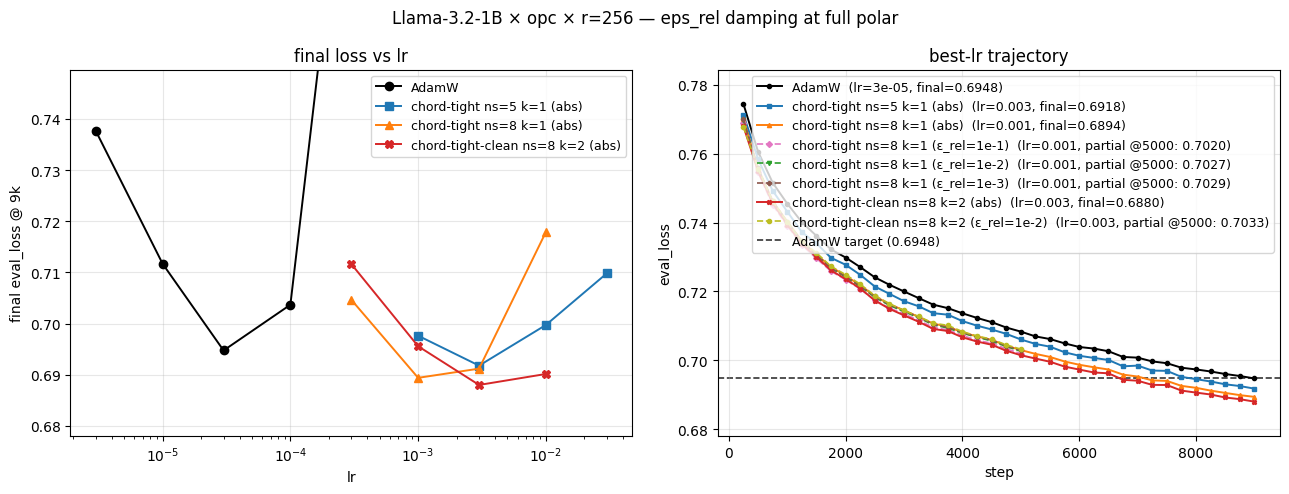

In [ ]:
LLAMA = [
    'adamw_robustness_llama32_1b_opc_r256_blackwell',
    'adamw_robustness_llama32_1b_opc_r256_extend_left_blackwell',
    'chord_tight_robustness_llama32_1b_opc_r256_blackwell',                 # ns5 abs (partial ref)
    'chord_tight_robustness_llama32_1b_opc_r256_ns8_blackwell',             # full abs = ns8
    'chord_tight_clean_ns8_picard_ablation_llama32_1b_opc_r256_blackwell',  # picard2 abs ns8
    'epsrel_fullpolar_r256_llama_ctk1_blackwell',                           # eps_rel {1e-3,1e-2,1e-1} ns8 (new)
    'epsrel_fullpolar_r256_llama_cleank2_blackwell',                        # picard2 + eps_rel ns8 (combo, new)
]
tdf_l, sdf_l = render_damp(LLAMA, 'Llama-3.2-1B × opc × r=256 — eps_rel damping at full polar')

## OLMo-2-1B × opc × r=64 — full-polar optimum ≈ 1e-2 (k1) / 3e-2 (k2)

In [ ]:
OLMO_R64 = [
    'adamw_phase_L_lrsweep_r64_blackwell',
    'adamw_phase_L_lrsweep_r64_extension_blackwell',
    'chord_tight_phase_L_lrsweep_r64_blackwell',                       # ns5 abs (partial ref)
    'chord_tight_phase_L_lrsweep_r64_extension_blackwell',
    'chord_tight_polar_express_phase_L_lrsweep_r64_gpuxl_h200',        # full abs = polar-express (k1)
    'chord_tight_polar_express_phase_L_lrsweep_r64_gpuxl_h200_resub',
    'chord_tight_polar_express_phase_L_lrsweep_r64_lr1e-3_blackwell',  # adds lr=1e-3 to k1 basin
    'chord_tight_clean_polar_express_phase_L_lrsweep_r64_k2_gpuxl_h200',  # full abs polar-express (k2 clean)
    'epsrel_fullpolar_r64_olmo_ctk1_blackwell',                       # eps_rel {1e-3,1e-1} ns8 k1 (new)
    'epsrel_fullpolar_r64_olmo_cleank2_blackwell',                    # eps_rel 1e-2 ns8 k2 (new)
]
tdf_o64, sdf_o64 = render_damp(OLMO_R64, 'OLMo-2-1B × opc × r=64 — eps_rel damping at full polar')

## Llama-3.2-1B × opc × r=64 — full-polar optimum ≈ 3e-3; does eps_rel hurt?

In [ ]:
LLAMA_R64 = [
    'adamw_robustness_llama32_1b_opc_r64_blackwell',
    'chord_tight_robustness_llama32_1b_opc_r64_blackwell',                 # ns5 abs (partial ref)
    'chord_tight_robustness_llama32_1b_opc_r64_extend_left_blackwell',
    'chord_tight_robustness_llama32_1b_opc_r64_ns8_blackwell',             # full abs = ns8 (k1)
    'chord_tight_clean_ns8_picard_ablation_llama32_1b_opc_r64_blackwell',  # picard2 abs ns8 (k2)
    'chord_tight_clean_ns8_picard_ablation_llama32_1b_opc_r64_extend_left_blackwell',
    'epsrel_fullpolar_r64_llama_ctk1_blackwell',                           # eps_rel {1e-3,1e-2,1e-1} ns8 (new)
    'epsrel_fullpolar_r64_llama_cleank2_blackwell',                        # picard2 + eps_rel ns8 (new)
]
tdf_l64, sdf_l64 = render_damp(LLAMA_R64, 'Llama-3.2-1B × opc × r=64 — eps_rel damping at full polar')